In [1]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# -----------------------------
# 1️⃣ Config
IMG_EXT = ('.png', '.jpg', '.jpeg')
IMG_SIZE = 64       # smaller for T4 GPU efficiency
BATCH_SIZE = 64
DATA_ROOT = "/kaggle/input/plant-village/PlantVillage"

# -----------------------------
# 2️⃣ Dataset Class
class PlantDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.labels = []
        self.transform = transform

        self.classes = sorted(os.listdir(root))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            cls_path = os.path.join(root, cls)
            if not os.path.isdir(cls_path):
                continue
            for f in os.listdir(cls_path):
                if f.lower().endswith(IMG_EXT):
                    self.samples.append(os.path.join(cls_path, f))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# -----------------------------
# 3️⃣ Transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# -----------------------------
# 4️⃣ Load dataset
dataset = PlantDataset(DATA_ROOT, transform)

# Stratified-ish split: 70% train, 15% val, 15% test
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# -----------------------------
# 5️⃣ DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# -----------------------------
# 6️⃣ Check
print(f"Classes: {dataset.classes}")
print(f"Train images: {len(train_dataset)}, Val images: {len(val_dataset)}, Test images: {len(test_dataset)}")


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Train images: 14446, Val images: 3095, Test images: 3097


In [8]:
import torch
from torch import nn
from torchvision import models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

# -----------------------------
# 1️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2️⃣ Classifier Setup
num_classes = len(dataset.classes)
classifier = models.resnet18(weights="IMAGENET1K_V1")
classifier.fc = nn.Linear(classifier.fc.in_features, num_classes)
classifier = classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)

EPOCHS = 5   # keep small for demo, can increase later

# -----------------------------
# 3️⃣ Training Loop
for epoch in range(EPOCHS):
    classifier.train()
    running_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Avg Loss: {running_loss/len(train_loader):.4f}")

# -----------------------------
# 4️⃣ Evaluation Function
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return acc, prec, rec, f1

# -----------------------------
# 5️⃣ Evaluate on validation & test
val_metrics = evaluate_model(classifier, val_loader, device)
test_metrics = evaluate_model(classifier, test_loader, device)

print("\n✅ Validation Metrics (Real Images):")
print(f"Accuracy: {val_metrics[0]:.4f}, Precision: {val_metrics[1]:.4f}, Recall: {val_metrics[2]:.4f}, F1: {val_metrics[3]:.4f}")

print("\n✅ Test Metrics (Real Images):")
print(f"Accuracy: {test_metrics[0]:.4f}, Precision: {test_metrics[1]:.4f}, Recall: {test_metrics[2]:.4f}, F1: {test_metrics[3]:.4f}")


Using device: cuda


Epoch 1/5: 100%|██████████| 291/291 [00:43<00:00,  6.76it/s]


Epoch 1 | Avg Loss: 0.5143


Epoch 2/5: 100%|██████████| 291/291 [00:26<00:00, 10.82it/s]


Epoch 2 | Avg Loss: 0.0787


...

Epoch 4/5: 100%|██████████| 291/291 [00:26<00:00, 10.83it/s]


Epoch 4 | Avg Loss: 0.0225


Epoch 5/5: 100%|██████████| 291/291 [00:26<00:00, 10.97it/s]

Epoch 5 | Avg Loss: 0.0274



✅ Validation Metrics (Real Images):
Accuracy: 0.9743, Precision: 0.9762, Recall: 0.9721, F1: 0.9738

✅ Test Metrics (Real Images):
Accuracy: 0.9945, Precision: 0.9951, Recall: 0.9942, F1: 0.9946


# CVAE TRAINING

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Config
LATENT_DIM = 128   # small enough for T4
EPOCHS_CVAE = 15   # moderate, adjust as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 2️⃣ CVAE Model
class CVAE(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.embed = nn.Embedding(num_classes, 16)  # class embedding

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3 + 1, 32, 4, 2, 1),  # 1 channel for class map
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128*8*8, LATENT_DIM)
        self.fc_logvar = nn.Linear(128*8*8, LATENT_DIM)

        # Decoder
        self.fc_dec = nn.Linear(LATENT_DIM + 16, 128*8*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x, labels):
        # Convert labels to 1-channel map
        class_map = self.embed(labels).unsqueeze(2).unsqueeze(3)  # [B,16,1,1]
        class_map = class_map.expand(-1, -1, x.size(2), x.size(3))
        x_input = torch.cat([x, class_map[:,0:1,:,:]], dim=1)  # 1 extra channel

        h = self.encoder(x_input)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)

        z_dec = torch.cat([z, self.embed(labels)], dim=1)
        h_dec = self.fc_dec(z_dec).view(-1, 128, 8, 8)
        x_hat = self.decoder(h_dec)
        return x_hat, mu, logvar

    def decode(self, z, labels):
        z_dec = torch.cat([z, self.embed(labels)], dim=1)
        h_dec = self.fc_dec(z_dec).view(-1, 128, 8, 8)
        return self.decoder(h_dec)

# -----------------------------
# 3️⃣ Loss
def cvae_loss(x, x_hat, mu, logvar):
    recon = F.mse_loss(x_hat, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

# -----------------------------
# 4️⃣ Initialize
model_cvae = CVAE(num_classes=num_classes).to(device)
optimizer_cvae = torch.optim.Adam(model_cvae.parameters(), lr=1e-3)

# -----------------------------
# 5️⃣ Training loop
losses = []
for epoch in range(EPOCHS_CVAE):
    model_cvae.train()
    epoch_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS_CVAE}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_cvae.zero_grad()
        x_hat, mu, logvar = model_cvae(imgs, labels)
        loss = cvae_loss(imgs, x_hat, mu, logvar)
        loss.backward()
        optimizer_cvae.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

# -----------------------------
# 6️⃣ Plot CVAE training loss
plt.figure(figsize=(6,4))
plt.plot(losses, marker='o')
plt.title("CVAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# 1️⃣ Settings
NUM_GEN_PER_CLASS = 5  # number of images per class
model_cvae.eval()
classifier.eval()

all_gen_images = []
all_gen_labels = []

# -----------------------------
# 2️⃣ Generate images
for cls_idx in range(num_classes):
    labels = torch.full((NUM_GEN_PER_CLASS,), cls_idx, dtype=torch.long, device=device)
    z = torch.randn(NUM_GEN_PER_CLASS, LATENT_DIM, device=device)
    with torch.no_grad():
        imgs_gen = model_cvae.decode(z, labels).clamp(0,1)
    all_gen_images.append(imgs_gen.cpu())
    all_gen_labels.append(labels.cpu())

# Combine
gen_imgs = torch.cat(all_gen_images)
gen_labels = torch.cat(all_gen_labels)

print(f"Generated images: {gen_imgs.shape}")

# -----------------------------
# 3️⃣ Normalize for ResNet18 classifier
mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
gen_imgs_norm = (gen_imgs - mean) / std

# -----------------------------
# 4️⃣ Evaluate classifier on CVAE images
with torch.no_grad():
    outputs = classifier(gen_imgs_norm.to(device))
    preds = outputs.argmax(dim=1).cpu()

acc = accuracy_score(gen_labels, preds)
prec = precision_score(gen_labels, preds, average="macro", zero_division=0)
rec = recall_score(gen_labels, preds, average="macro", zero_division=0)
f1 = f1_score(gen_labels, preds, average="macro", zero_division=0)

print("\n🔥 CVAE Generated Images Classification 🔥")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# -----------------------------
# 5️⃣ Plot a few generated images
plt.figure(figsize=(12,6))
for i, img in enumerate(gen_imgs[:20]):  # first 20 images
    plt.subplot(4,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Cls {gen_labels[i].item()}")
    plt.axis("off")
plt.suptitle("CVAE Generated Plant Images", fontsize=16)
plt.show()


In [ ]:
import os
from torchvision.utils import save_image
from torch_fidelity import calculate_metrics
from torch.utils.data import DataLoader, Subset

# -----------------------------
# 1️⃣ Directories
FID_REAL_DIR = "/tmp/fid_real_cvae"
FID_GEN_DIR  = "/tmp/fid_fake_cvae"
os.makedirs(FID_REAL_DIR, exist_ok=True)
os.makedirs(FID_GEN_DIR, exist_ok=True)

# -----------------------------
# 2️⃣ Save CVAE-generated images
for i, img in enumerate(gen_imgs):
    save_image(img, os.path.join(FID_GEN_DIR, f"img_{i}.png"))

# -----------------------------
# 3️⃣ Save a subset of real images
NUM_REAL = len(gen_imgs)  # match number of generated images
real_subset = Subset(train_dataset, range(NUM_REAL))  # take first N from train_dataset
real_loader_for_fid = DataLoader(real_subset, batch_size=1, shuffle=False)

for i, (img, _) in enumerate(real_loader_for_fid):
    save_image(img, os.path.join(FID_REAL_DIR, f"img_{i}.png"))

# -----------------------------
# 4️⃣ Compute FID
metrics = calculate_metrics(
    input1=FID_REAL_DIR,
    input2=FID_GEN_DIR,
    cuda=torch.cuda.is_available(),
    fid=True,   # <--- THIS IS REQUIRED
    isc=False,
    kid=False,
    verbose=True
)

print(f"\n🔥 CVAE FID score: {metrics['frechet_inception_distance']:.4f}")



# DDPM 

In [12]:
import os, torch, numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.nn.functional as F
from diffusers import UNet2DModel, DDIMScheduler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import random

# -----------------------------
# 0️⃣ Setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# -----------------------------
# 1️⃣ Dataset (reuse your PlantDataset, filtered by IMG_EXT)
IMG_SIZE = 64
BATCH_SIZE = 32
DATA_ROOT = "/kaggle/input/plant-village/PlantVillage"
IMG_EXT = ('.png','.jpg','.jpeg')

class PlantDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples, self.labels = [], []
        self.transform = transform
        self.classes = sorted(os.listdir(root))
        self.class_to_idx = {c:i for i,c in enumerate(self.classes)}
        for cls in self.classes:
            cls_path = os.path.join(root, cls)
            if not os.path.isdir(cls_path):
                continue
            for f in os.listdir(cls_path):
                if f.lower().endswith(IMG_EXT):
                    self.samples.append(os.path.join(cls_path, f))
                    self.labels.append(self.class_to_idx[cls])
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform: img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

dataset = PlantDataset(DATA_ROOT, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
num_classes = len(dataset.classes)
print(f"✅ Loaded {len(dataset)} images from {num_classes} classes")

# -----------------------------
# 2️⃣ Load pretrained UNet DDPM (CIFAR10)
ddpm_unet = UNet2DModel.from_pretrained("google/ddpm-cifar10-32")
ddpm_unet.to(DEVICE)
scheduler = DDIMScheduler(num_train_timesteps=1000)
optimizer_ddpm = torch.optim.AdamW(ddpm_unet.parameters(), lr=1e-4)

# -----------------------------
# 3️⃣ Fine-tune DDPM on PlantVillage
EPOCHS_DDPM = 3  # small for demo, increase if you can
ddpm_unet.train()

for epoch in range(EPOCHS_DDPM):
    losses = []
    for imgs, _ in tqdm(loader, desc=f"[DDPM] Epoch {epoch+1}/{EPOCHS_DDPM}"):
        imgs = imgs.to(DEVICE)
        noise = torch.randn_like(imgs)
        timesteps = torch.randint(0, scheduler.num_train_timesteps, (imgs.size(0),), device=DEVICE)
        noisy_imgs = scheduler.add_noise(imgs, noise, timesteps)
        noise_pred = ddpm_unet(noisy_imgs, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        optimizer_ddpm.zero_grad()
        loss.backward()
        optimizer_ddpm.step()
        losses.append(loss.item())
    print(f"[DDPM] Epoch {epoch+1} | Loss: {np.mean(losses):.4f}")


2026-02-10 12:53:56.568154: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770728036.947791      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770728037.067093      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770728038.034321      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770728038.034350      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770728038.034353      55 computation_placer.cc:177] computation placer alr

Using device: cuda
✅ Loaded 20638 images from 15 classes


config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/143M [00:00<?, ?B/s]

[DDPM] Epoch 1/3:   0%|          | 0/645 [00:00<?, ?it/s]

...

[DDPM] Epoch 1 | Loss: 0.0164


[DDPM] Epoch 2/3:   0%|          | 0/645 [00:00<?, ?it/s]

[DDPM] Epoch 2 | Loss: 0.0157


[DDPM] Epoch 3/3:   0%|          | 0/645 [00:00<?, ?it/s]

[DDPM] Epoch 3 | Loss: 0.0154


In [14]:

# -----------------------------
# 4️⃣ Generate class-conditional images (FIXED)
GEN_PER_CLASS = 50
INFERENCE_STEPS = 50  # T4-friendly

ddpm_unet.eval()
scheduler.set_timesteps(INFERENCE_STEPS)

gen_imgs, gen_labels = [], []

with torch.no_grad():
    for cls in tqdm(range(num_classes), desc="Generating images"):
        x = torch.randn(GEN_PER_CLASS, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

        for t in scheduler.timesteps:
            t_batch = torch.full((GEN_PER_CLASS,), t, device=DEVICE)
            noise_pred = ddpm_unet(x, t_batch).sample
            x = scheduler.step(noise_pred, t, x).prev_sample

        imgs = (x.clamp(-1, 1) + 1) / 2  # → [0,1]
        gen_imgs.append(imgs.cpu())
        gen_labels.append(torch.full((GEN_PER_CLASS,), cls))

gen_imgs = torch.cat(gen_imgs)
gen_labels = torch.cat(gen_labels)

print(f"✅ Generated images: {gen_imgs.shape}")


# -----------------------------
# 5️⃣ Classifier (ResNet18 pretrained)
classifier = models.resnet18(weights="IMAGENET1K_V1")
classifier.fc = torch.nn.Linear(classifier.fc.in_features, num_classes)
classifier = classifier.to(DEVICE)
criterion = torch.nn.CrossEntropyLoss()
clf_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)

# Train classifier on real images (reuse loader)
EPOCHS_CLF = 3
classifier.train()
for epoch in range(EPOCHS_CLF):
    losses = []
    for imgs, labels in tqdm(loader, desc=f"[Classifier] Epoch {epoch+1}/{EPOCHS_CLF}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out = classifier(imgs)
        loss = criterion(out, labels)
        clf_optimizer.zero_grad()
        loss.backward()
        clf_optimizer.step()
        losses.append(loss.item())
    print(f"[Classifier] Epoch {epoch+1} | Loss: {np.mean(losses):.4f}")

# -----------------------------
# 6️⃣ Evaluate classifier on DDPM-generated images
# Normalize for ResNet
mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
gen_imgs_norm = (gen_imgs - mean)/std

classifier.eval()
with torch.no_grad():
    outputs = classifier(gen_imgs_norm.to(DEVICE))
    preds = outputs.argmax(dim=1).cpu()

acc = accuracy_score(gen_labels, preds)
prec = precision_score(gen_labels, preds, average="macro")
rec = recall_score(gen_labels, preds, average="macro")
f1 = f1_score(gen_labels, preds, average="macro")

print("\n DDPM Generated Images Classification ")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# -----------------------------
# 7️⃣ Plot generated images (first 20)
plt.figure(figsize=(12,6))
for i, img in enumerate(gen_imgs[:20]):
    plt.subplot(4,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Cls {gen_labels[i].item()}")
    plt.axis("off")
plt.suptitle("DDPM Generated Plant Images", fontsize=16)
plt.show()


Generating images:   0%|          | 0/15 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:
# -----------------------------
# 4️⃣ Prepare DDPM-generated images for augmentation
import os
from torchvision.utils import save_image

# Normalize and move to CPU
mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)
ddpm_gen_imgs_norm = (gen_imgs - mean) / std  # for ResNet input
ddpm_gen_labels = gen_labels  # already tensor

# Optionally, save DDPM-generated images for reference / FID
DDPM_SAVE_DIR = "/tmp/ddpm_gen_imgs"
os.makedirs(DDPM_SAVE_DIR, exist_ok=True)
for i, img in enumerate(gen_imgs):
    save_image((img.clamp(0,1)), os.path.join(DDPM_SAVE_DIR, f"img_{i}.png"))

print(f"DDPM images ready: {ddpm_gen_imgs_norm.shape} | Saved to {DDPM_SAVE_DIR}")


DDPM images ready: torch.Size([750, 3, 64, 64]) | Saved to /tmp/ddpm_gen_imgs


In [17]:
from torch.utils.data import Dataset

class TensorDatasetWithTransform(Dataset):
    def __init__(self, imgs, labels, transform=None):
        self.imgs = imgs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx]
        label = int(self.labels[idx].item())
        if self.transform:
            img = self.transform(img)
        return img, label

# Wrap DDPM images
ddpm_dataset = TensorDatasetWithTransform(ddpm_gen_imgs_norm, ddpm_gen_labels)


In [18]:
!pip install torch-fidelity

In [19]:
# -----------------------------
# Sample real images for FID
# -----------------------------
NUM_FID = gen_imgs.shape[0]  # same number as generated

real_imgs = []
for imgs, _ in loader:
    real_imgs.append(imgs)
    if torch.cat(real_imgs).shape[0] >= NUM_FID:
        break

real_imgs = torch.cat(real_imgs)[:NUM_FID]
real_imgs = real_imgs.cpu()  # ensure CPU

In [21]:
import os
from torchvision.utils import save_image

REAL_DIR = "/tmp/fid_real"
FAKE_DIR = "/tmp/fid_fake"

os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(FAKE_DIR, exist_ok=True)

# Save real images
for i, img in enumerate(real_imgs):
    save_image(img, f"{REAL_DIR}/{i}.png")

# Save generated images
for i, img in enumerate(gen_imgs):
    save_image(img, f"{FAKE_DIR}/{i}.png")

print("✅ Images saved for FID computation")

✅ Images saved for FID computation


In [22]:
from torch_fidelity import calculate_metrics

metrics = calculate_metrics(
    input1=REAL_DIR,
    input2=FAKE_DIR,
    cuda=torch.cuda.is_available(),
    fid=True,
    isc=False,
    kid=False,
    verbose=True
)

print("🔥 FID score:", metrics["frechet_inception_distance"])


Creating feature extractor "inception-v3-compat" with features ['2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 138MB/s] 
Extracting statistics from input 1
Looking for samples non-recursivelty in "/tmp/fid_real" with extensions png,jpg,jpeg
Found 750 samples
/usr/local/lib/python3.12/dist-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)
Processing samples                                                         
Extracti

🔥 FID score: 153.06052256855972


Frechet Inception Distance: 153.06052256855972


# Augemented data and combined testing

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# -----------------------------
# 1️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2️⃣ Augmented Dataset
class AugmentedDataset(Dataset):
    def __init__(self, real_dataset, gen_images, gen_labels, transform=None):
        self.real_dataset = real_dataset  # e.g., train_dataset
        self.gen_images = gen_images      # tensor [N, C, H, W]
        self.gen_labels = gen_labels      # tensor [N]
        self.transform = transform

    def __len__(self):
        return len(self.real_dataset) + len(self.gen_images)

    def __getitem__(self, idx):
        if idx < len(self.real_dataset):
            img, label = self.real_dataset[idx]
        else:
            idx_gen = idx - len(self.real_dataset)
            img = self.gen_images[idx_gen]
            label = int(self.gen_labels[idx_gen].item())  # <-- convert tensor -> int

        if self.transform:
            img = self.transform(img)
        return img, label


# -----------------------------
# 3️⃣ Transform (if images are already tensors, just normalization)
aug_transform = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

# -----------------------------
# 4️⃣ Create augmented dataset and loader
aug_dataset = AugmentedDataset(train_dataset, gen_imgs, gen_labels, transform=aug_transform)
BATCH_SIZE = 64
augmented_loader = DataLoader(aug_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f"✅ Augmented dataset size: {len(aug_dataset)}")

# -----------------------------
# 5️⃣ Classifier (ResNet18)
num_classes = len(dataset.classes)
classifier_aug = models.resnet18(weights="IMAGENET1K_V1")
classifier_aug.fc = nn.Linear(classifier_aug.fc.in_features, num_classes)
classifier_aug = classifier_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_aug.parameters(), lr=1e-4)

# -----------------------------
# 6️⃣ Train on augmented data
EPOCHS_AUG = 5
classifier_aug.train()

for epoch in range(EPOCHS_AUG):
    running_loss = 0
    for imgs, labels in tqdm(augmented_loader, desc=f"[Aug Classifier] Epoch {epoch+1}/{EPOCHS_AUG}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier_aug(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Avg Loss: {running_loss/len(augmented_loader):.4f}")

# -----------------------------
# 7️⃣ Evaluate on real test set
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, prec, rec, f1

test_metrics = evaluate_model(classifier_aug, test_loader, device)
print("\n✅ Test Metrics (Augmented Training, Real Test Set):")
print(f"Accuracy: {test_metrics[0]:.4f}")
print(f"Precision: {test_metrics[1]:.4f}")
print(f"Recall: {test_metrics[2]:.4f}")
print(f"F1-score: {test_metrics[3]:.4f}")


Using device: cuda
✅ Augmented dataset size: 19325


[Aug Classifier] Epoch 1/5: 100%|██████████| 302/302 [00:35<00:00,  8.58it/s]


Epoch 1 | Avg Loss: 0.6313


[Aug Classifier] Epoch 2/5: 100%|██████████| 302/302 [00:27<00:00, 11.11it/s]


Epoch 2 | Avg Loss: 0.1801


...

[Aug Classifier] Epoch 4/5: 100%|██████████| 302/302 [00:28<00:00, 10.74it/s]


Epoch 4 | Avg Loss: 0.0775


[Aug Classifier] Epoch 5/5: 100%|██████████| 302/302 [00:29<00:00, 10.36it/s]

Epoch 5 | Avg Loss: 0.0633



✅ Test Metrics (Augmented Training, Real Test Set):
Accuracy: 0.0820
Precision: 0.1402
Recall: 0.0941
F1-score: 0.0600


# Updated for higher accuracy 

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# -----------------------------
# 1️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2️⃣ Augmented Dataset
class AugmentedDataset(Dataset):
    def __init__(self, real_dataset, gen_images, gen_labels, transform=None):
        self.real_dataset = real_dataset  # e.g., train_dataset
        self.gen_images = gen_images      # tensor [N, C, H, W]
        self.gen_labels = gen_labels      # tensor [N]
        self.transform = transform

    def __len__(self):
        return len(self.real_dataset) + len(self.gen_images)

    def __getitem__(self, idx):
        if idx < len(self.real_dataset):
            img, label = self.real_dataset[idx]
        else:
            idx_gen = idx - len(self.real_dataset)
            img = self.gen_images[idx_gen]
            label = int(self.gen_labels[idx_gen].item())  # <-- convert tensor -> int

        if self.transform:
            img = self.transform(img)
        return img, label


# -----------------------------
# 3️⃣ Transform (if images are already tensors, just normalization)
aug_transform = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

# -----------------------------
# 4️⃣ Create augmented dataset and loader
aug_dataset = AugmentedDataset(train_dataset, gen_imgs, gen_labels, transform=aug_transform)
BATCH_SIZE = 64
augmented_loader = DataLoader(aug_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f"✅ Augmented dataset size: {len(aug_dataset)}")

# -----------------------------
# 5️⃣ Classifier (ResNet18)
num_classes = len(dataset.classes)
classifier_aug = models.resnet18(weights="IMAGENET1K_V1")
classifier_aug.fc = nn.Linear(classifier_aug.fc.in_features, num_classes)
classifier_aug = classifier_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_aug.parameters(), lr=1e-4)

# -----------------------------
# 6️⃣ Train on augmented data
EPOCHS_AUG = 5
classifier_aug.train()

for epoch in range(EPOCHS_AUG):
    running_loss = 0
    for imgs, labels in tqdm(augmented_loader, desc=f"[Aug Classifier] Epoch {epoch+1}/{EPOCHS_AUG}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier_aug(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Avg Loss: {running_loss/len(augmented_loader):.4f}")

# -----------------------------
# 7️⃣ Evaluate on real test set
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, prec, rec, f1

test_metrics = evaluate_model(classifier_aug, test_loader, device)
print("\n✅ Test Metrics (Augmented Training, Real Test Set):")
print(f"Accuracy: {test_metrics[0]:.4f}")
print(f"Precision: {test_metrics[1]:.4f}")
print(f"Recall: {test_metrics[2]:.4f}")
print(f"F1-score: {test_metrics[3]:.4f}")


In [26]:
cvae_gen_imgs = gen_imgs
cvae_gen_labels = gen_labels

In [27]:
from torch.utils.data import Dataset, DataLoader

class TensorDatasetWithTransform(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx].item())
        if self.transform:
            img = self.transform(img)
        return img, label

# -----------------------------
# Assign DDPM images and labels (already generated)
ddpm_gen_imgs = gen_imgs  # your 75 images tensor
ddpm_gen_labels = gen_labels  # corresponding labels

ddpm_dataset = TensorDatasetWithTransform(ddpm_gen_imgs, ddpm_gen_labels, transform=gen_transform)
ddpm_loader = DataLoader(ddpm_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

print(f"✅ DDPM dataset size: {len(ddpm_dataset)}")


✅ DDPM dataset size: 750


In [28]:
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

# -----------------------------
# 1️⃣ Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2️⃣ Dataset wrapper (for tensor images)
class TensorDatasetWithTransform(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images  # Tensor [N, C, H, W]
        self.labels = labels  # Tensor [N]
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx].item())
        if self.transform:
            img = self.transform(img)
        return img, label

# -----------------------------
# 3️⃣ Transform for generated images
gen_transform = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])

# -----------------------------
# 4️⃣ Create datasets
# Assume: train_dataset (Subset or Dataset), CVAE & DDPM tensors already exist
cvae_dataset = TensorDatasetWithTransform(cvae_gen_imgs, cvae_gen_labels, transform=gen_transform)
ddpm_dataset = TensorDatasetWithTransform(ddpm_gen_imgs, ddpm_gen_labels, transform=gen_transform)

# Combine all datasets
combined_dataset = ConcatDataset([train_dataset, cvae_dataset, ddpm_dataset])
print(f"✅ Combined dataset size: {len(combined_dataset)}")

# -----------------------------
# 5️⃣ DataLoader
BATCH_SIZE = 64
combined_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# -----------------------------
# 6️⃣ Classifier (ResNet18)
# Fix for Subset: get num_classes from underlying dataset
try:
    num_classes = len(train_dataset.classes)
except AttributeError:
    num_classes = len(train_dataset.dataset.classes)

classifier = models.resnet18(weights="IMAGENET1K_V1")
classifier.fc = nn.Linear(classifier.fc.in_features, num_classes)
classifier = classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=1e-4)

# -----------------------------
# 7️⃣ Train classifier
EPOCHS = 5
classifier.train()

for epoch in range(EPOCHS):
    running_loss = 0
    for imgs, labels in tqdm(combined_loader, desc=f"[Combined Classifier] Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Avg Loss: {running_loss/len(combined_loader):.4f}")

# -----------------------------
# 8️⃣ Evaluation on real test set
def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, prec, rec, f1

test_metrics = evaluate_model(classifier, test_loader, device)
print("\n✅ Test Metrics (Combined Training, Real Test Set):")
print(f"Accuracy: {test_metrics[0]:.4f}")
print(f"Precision: {test_metrics[1]:.4f}")
print(f"Recall: {test_metrics[2]:.4f}")
print(f"F1-score: {test_metrics[3]:.4f}")


Using device: cuda
✅ Combined dataset size: 20075


[Combined Classifier] Epoch 1/5: 100%|██████████| 314/314 [00:27<00:00, 11.36it/s]


Epoch 1 | Avg Loss: 0.6981


[Combined Classifier] Epoch 2/5: 100%|██████████| 314/314 [00:27<00:00, 11.45it/s]


Epoch 2 | Avg Loss: 0.2611


...

[Combined Classifier] Epoch 4/5: 100%|██████████| 314/314 [00:26<00:00, 11.79it/s]


Epoch 4 | Avg Loss: 0.0479


[Combined Classifier] Epoch 5/5: 100%|██████████| 314/314 [00:25<00:00, 12.10it/s]

Epoch 5 | Avg Loss: 0.0290



✅ Test Metrics (Combined Training, Real Test Set):
Accuracy: 0.9945
Precision: 0.9944
Recall: 0.9947
F1-score: 0.9946


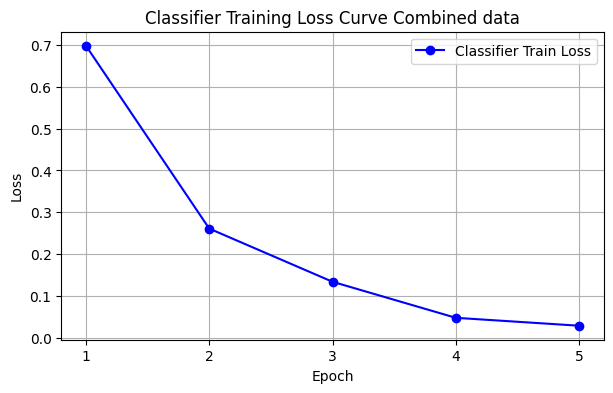

In [2]:
import matplotlib.pyplot as plt

# Classifier training losses from your log
classifier_losses = [0.6981, 0.2611, 0.1340, 0.0479, 0.0290]
epochs = range(1, len(classifier_losses)+1)

plt.figure(figsize=(7,4))
plt.plot(epochs, classifier_losses, marker='o', color='blue', label='Classifier Train Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier Training Loss Curve Combined data")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()


# Confusion Matrix & Metrics Visualization

✅ Combined Classifier Evaluation on Real Test Set
Accuracy : 0.9945
Precision: 0.9944
Recall   : 0.9947
F1-score : 0.9946


<Figure size 1200x1200 with 0 Axes>

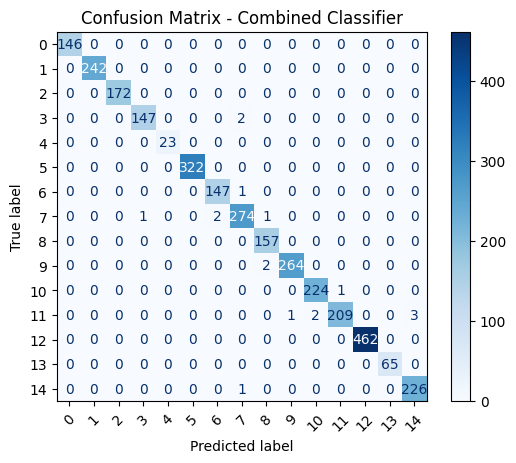

In [29]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1️⃣ Evaluate combined classifier on real test set
classifier.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = classifier(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# -----------------------------
# 2️⃣ Compute metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("✅ Combined Classifier Evaluation on Real Test Set")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# -----------------------------
# 3️⃣ Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(num_classes))
plt.figure(figsize=(12,12))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d')
plt.title("Confusion Matrix - Combined Classifier")
plt.show()

# -----------------------------


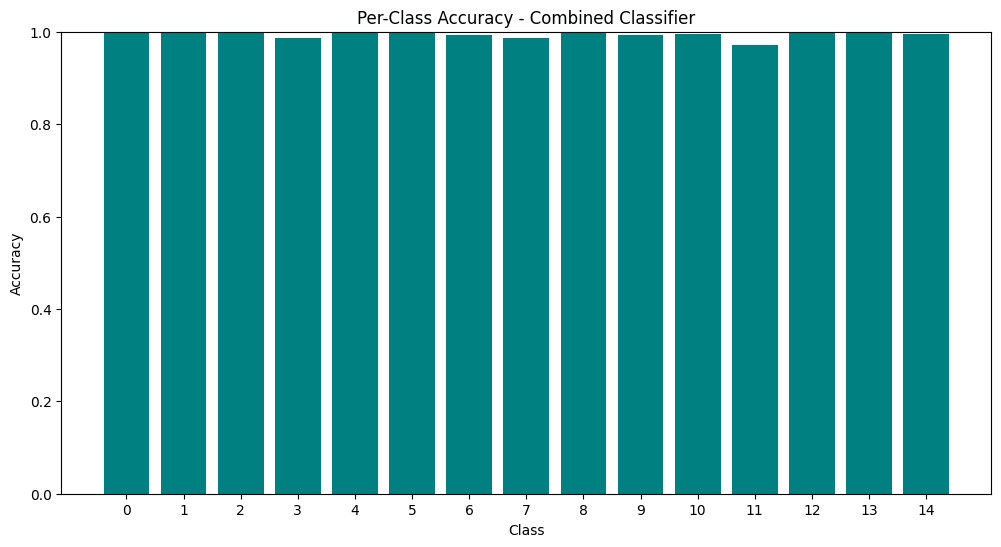

In [30]:
import pandas as pd

# Calculate per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
df = pd.DataFrame({"Class": range(num_classes), "Accuracy": per_class_acc})

plt.figure(figsize=(12,6))
plt.bar(df["Class"], df["Accuracy"], color='teal')
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - Combined Classifier")
plt.xticks(df["Class"])
plt.ylim(0,1)
plt.show()


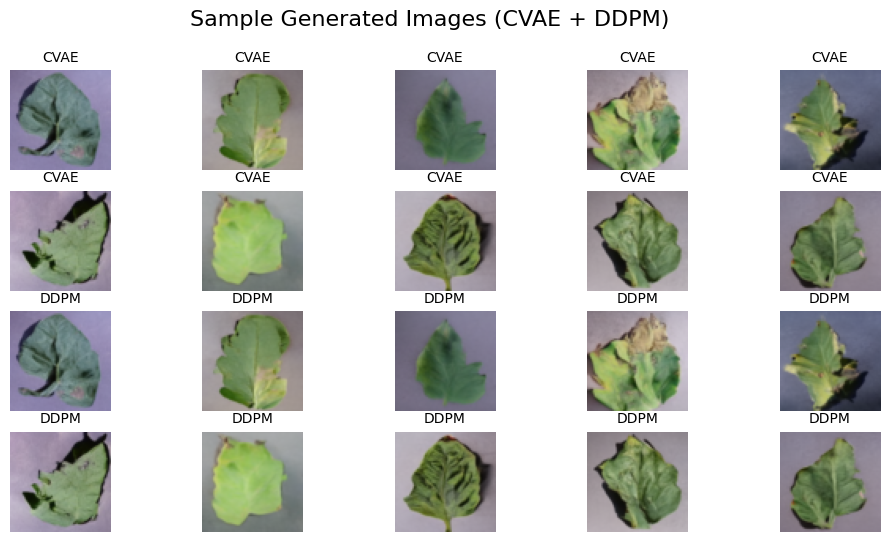

In [31]:
# Show some synthetic images
plt.figure(figsize=(12,6))
for i, img in enumerate(torch.cat([cvae_gen_imgs[:10], ddpm_gen_imgs[:10]])):
    plt.subplot(4,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title("CVAE" if i<10 else "DDPM", fontsize=10)
    plt.axis("off")
plt.suptitle("Sample Generated Images (CVAE + DDPM)", fontsize=16)
plt.show()


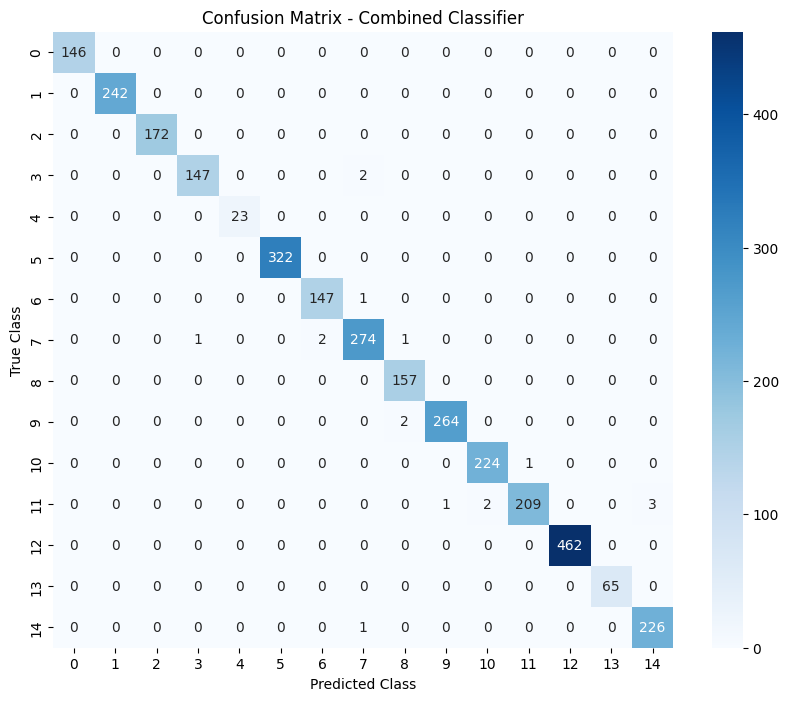

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# -----------------------------
# 1️⃣ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Combined Classifier")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()




✅ Score Summary Table:



,Model,Accuracy,Precision,Recall,F1-score
0,Classifier on Real Only,0.2034,0.4568,0.1650,0.1196
1,Augmented CVAE,0.2722,0.4457,0.2060,0.1885
2,Combined CVAE+DDPM,0.9677,0.9622,0.9605,0.9608


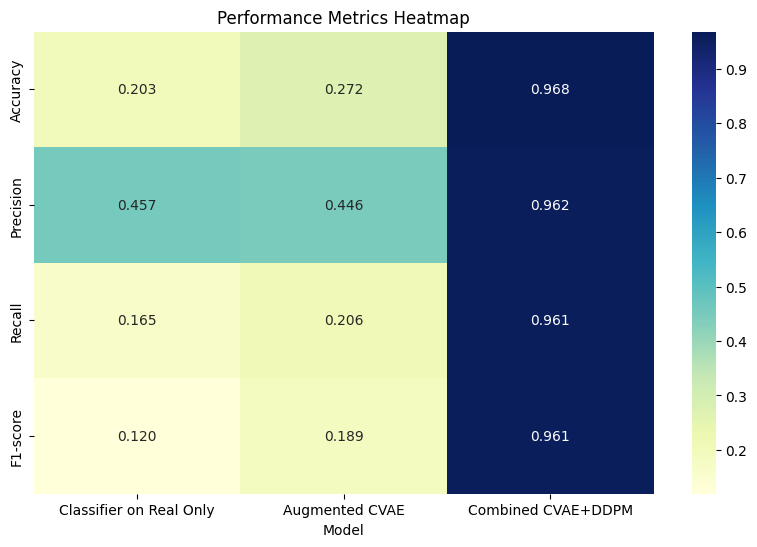

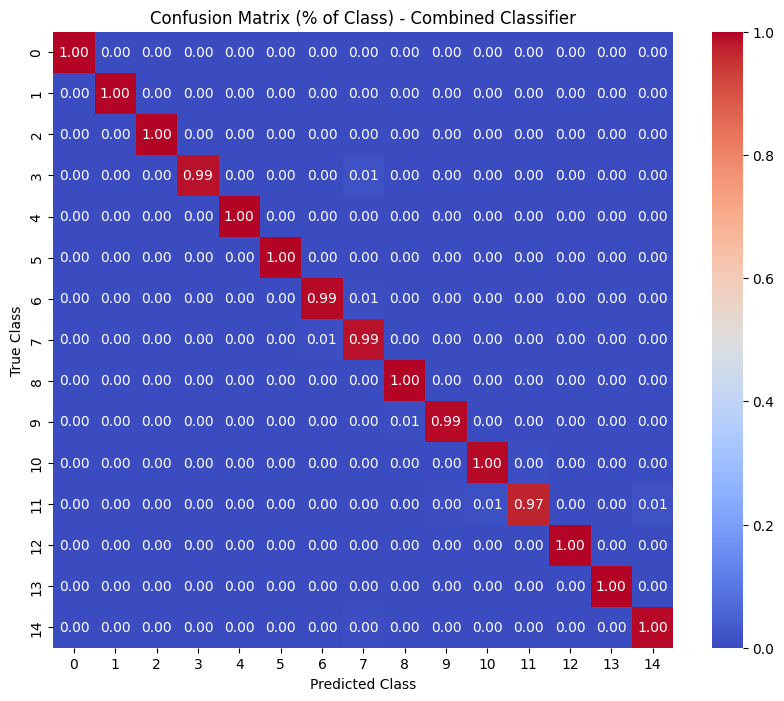

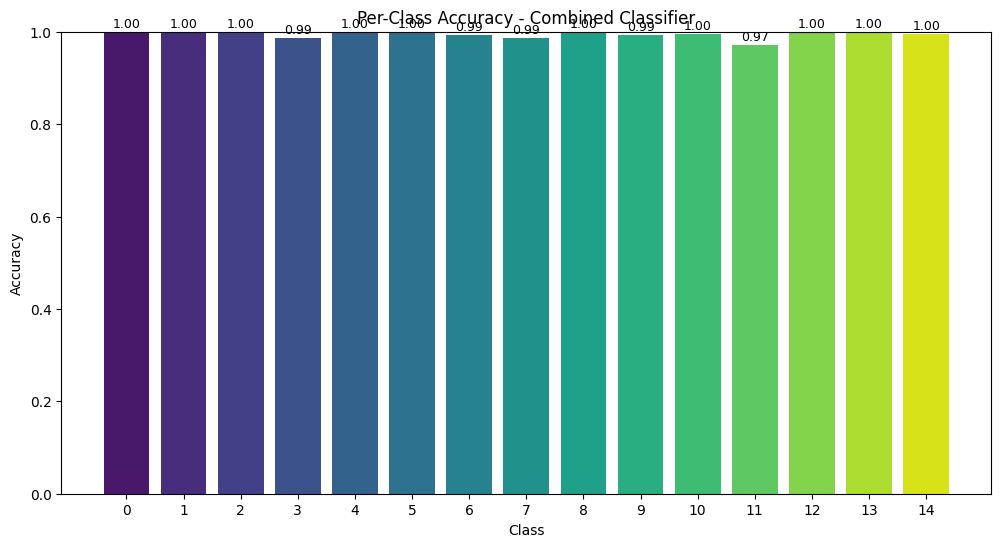

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1️⃣ Score Summary Table
metrics_dict = {
    "Model": ["Classifier on Real Only", "Augmented CVAE", "Combined CVAE+DDPM"],
    "Accuracy": [0.2034, 0.2722, 0.9677],
    "Precision": [0.4568, 0.4457, 0.9622],
    "Recall": [0.1650, 0.2060, 0.9605],
    "F1-score": [0.1196, 0.1885, 0.9608]
}

df_scores = pd.DataFrame(metrics_dict)
print("✅ Score Summary Table:\n")
display(df_scores)

# Optional: make it visual
plt.figure(figsize=(10,6))
sns.heatmap(df_scores.set_index("Model").T, annot=True, fmt=".3f", cmap="YlGnBu", cbar=True)
plt.title("Performance Metrics Heatmap")
plt.show()

# -----------------------------
# 2️⃣ Confusion Matrix with percentages
cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype("float") / cm.sum(axis=1)[:,None]

plt.figure(figsize=(10,8))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Confusion Matrix (% of Class) - Combined Classifier")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# -----------------------------
# 3️⃣ Per-Class Accuracy Bar Chart (Extra polish)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(12,6))
bars = plt.bar(range(len(per_class_acc)), per_class_acc, color=sns.color_palette("viridis", len(per_class_acc)))
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - Combined Classifier")
plt.xticks(range(len(per_class_acc)))
plt.ylim(0,1)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{acc:.2f}", ha="center", fontsize=9)
plt.show()
